In [12]:
import pandas as pd
import math
import os
import gc
import re
from collections import defaultdict

ENERGY_RATE = 1.20       
ENERGY_CAPACITY = 103    

# =========================
# DISTANCE FUNCTIONS
# =========================
def dist_euclidean(x1, y1, x2, y2):   # Euclidean distance (coordinates are in km-scale)
    return math.hypot(x1 - x2, y1 - y2)

def dist(i, j, coords):
    x1, y1 = coords[i]
    x2, y2 = coords[j]
    return dist_euclidean(x1, y1, x2, y2)

def energy_consumption(i, j, coords):
    return ENERGY_RATE * dist(i, j, coords)

def route_distance(route, coords):
    if len(route) < 2:
        return 0
    return sum(dist(route[k], route[k+1], coords) for k in range(len(route)-1))


def load_evrp_file(file_path):
    with open(file_path, 'r') as f:
        content = f.read()
    

    params = {}
    
    # OPTIMAL_VALUE
    opt_match = re.search(r'OPTIMAL_VALUE:\s*([\d.]+)', content)
    if opt_match:
        params['optimal_value'] = float(opt_match.group(1))
    
    # VEHICLES
    veh_match = re.search(r'VEHICLES:\s*(\d+)', content)
    if veh_match:
        params['vehicles'] = int(veh_match.group(1))
    
    # DIMENSION
    dim_match = re.search(r'DIMENSION:\s*(\d+)', content)
    if dim_match:
        params['dimension'] = int(dim_match.group(1))
    
    # STATIONS
    stat_match = re.search(r'STATIONS:\s*(\d+)', content)
    if stat_match:
        params['stations'] = int(stat_match.group(1))
    
    # CAPACITY (load)
    cap_match = re.search(r'CAPACITY:\s*([\d.]+)', content)
    if cap_match:
        params['load_capacity'] = float(cap_match.group(1))
    
    energy_cap_match = re.search(r'ENERGY_CAPACITY:\s*([\d.]+)', content)
    if energy_cap_match:
        params['energy_capacity'] = float(energy_cap_match.group(1))
    else:
        params['energy_capacity'] = ENERGY_CAPACITY
    
    energy_cons_match = re.search(r'ENERGY_CONSUMPTION:\s*([\d.]+)', content)
    if energy_cons_match:
        params['energy_consumption'] = float(energy_cons_match.group(1))
    else:
        params['energy_consumption'] = ENERGY_RATE
    
    print(f"   📊 Parameters: Vehicles={params.get('vehicles', '?')}, "
          f"Battery={params.get('energy_capacity', '?')} kWh, "
          f"Rate={params.get('energy_consumption', '?')} kWh/km, "
          f"Load Cap={params.get('load_capacity', '?')} kg")
    

    nodes = []  # (node_id, x, y, type)
    types_dict = {}
    
    coord_section = re.search(r'NODE_COORD_SECTION\n(.*?)(?:\nSTATION_COORD_SECTION|\nEOF|\Z)', content, re.DOTALL)
    
    if coord_section:
        coord_lines = coord_section.group(1).strip().split('\n')
        for line in coord_lines:
            parts = line.strip().split()
            if len(parts) >= 3:
                try:
                    node_id = str(int(float(parts[0])))
                    x = float(parts[1])
                    y = float(parts[2])
                    nodes.append((node_id, x, y, 'c'))  # default customer
                except:
                    pass
    
    station_section = re.search(r'STATION_COORD_SECTION\n(.*?)(?:\nDEMAND_SECTION|\nEOF|\Z)', content, re.DOTALL)
    
    if station_section:
        station_lines = station_section.group(1).strip().split('\n')
        for line in station_lines:
            parts = line.strip().split()
            if len(parts) >= 3:
                try:
                    node_id = str(int(float(parts[0])))
                    x = float(parts[1])
                    y = float(parts[2])
                    nodes.append((node_id, x, y, 'f'))  # station
                except:
                    pass
    
    if len(nodes) == 0:
        lines = content.strip().split('\n')
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 3:
                try:
                    x = float(parts[1])
                    y = float(parts[2])
                    node_id = str(int(float(parts[0])))
                    nodes.append((node_id, x, y, 'c'))
                except:
                    pass
    

    idx = {}
    coords = {}
    types = {}
    
    for i, (node_id, x, y, node_type) in enumerate(nodes):
        idx[node_id] = i
        coords[i] = (x, y)
        types[i] = node_type
    
    depot = idx.get('1', 0)
    types[depot] = 'd'
    
    # Count types
    num_customers = sum(1 for t in types.values() if t == 'c')
    num_stations = sum(1 for t in types.values() if t == 'f')
    
    print(f"   📍 Nodes: {len(nodes)} total | {num_customers} customers | {num_stations} stations | 1 depot")
    
    return nodes, coords, types, depot, params



def solve_diesel_cws(coords, types, depot, num_vehicles):
    customers = [i for i in coords if types[i] == 'c']
    
    if not customers:
        return [], 0
    
    n = len(customers)
    cust_list = list(customers)
    

    savings = []
    for i in range(n):
        for j in range(i + 1, n):
            ci = cust_list[i]
            cj = cust_list[j]
            saving = dist(depot, ci, coords) + dist(depot, cj, coords) - dist(ci, cj, coords)
            savings.append((saving, ci, cj))
    
    savings.sort(reverse=True, key=lambda x: x[0])
    
    routes = [[depot, c, depot] for c in customers]
    route_of = {c: i for i, route in enumerate(routes) for c in route if c != depot}
    route_first = {i: routes[i][1] for i in range(len(routes))}
    route_last = {i: routes[i][-2] for i in range(len(routes))}
    
    for saving, ci, cj in savings:
        if saving <= 0:
            break
        
        ri = route_of.get(ci)
        rj = route_of.get(cj)
        
        if ri is None or rj is None or ri == rj:
            continue
        if routes[ri] is None or routes[rj] is None:
            continue
        
        ci_is_end = (ci == route_first[ri] or ci == route_last[ri])
        cj_is_end = (cj == route_first[rj] or cj == route_last[rj])
        
        if not (ci_is_end and cj_is_end):
            continue
        
        route_i = routes[ri]
        route_j = routes[rj]
        route_i_clean = route_i[1:-1]
        route_j_clean = route_j[1:-1]
        
        best_clean = None
        best_len = float('inf')
        
        if ci == route_last[ri] and cj == route_first[rj]:
            new_clean = route_i_clean + route_j_clean
            new_route = [depot] + new_clean + [depot]
            d = route_distance(new_route, coords)
            if d < best_len:
                best_len = d
                best_clean = new_clean
        
        if ci == route_last[ri] and cj == route_last[rj]:
            new_clean = route_i_clean + route_j_clean[::-1]
            new_route = [depot] + new_clean + [depot]
            d = route_distance(new_route, coords)
            if d < best_len:
                best_len = d
                best_clean = new_clean
        
        if ci == route_first[ri] and cj == route_first[rj]:
            new_clean = route_i_clean[::-1] + route_j_clean
            new_route = [depot] + new_clean + [depot]
            d = route_distance(new_route, coords)
            if d < best_len:
                best_len = d
                best_clean = new_clean
        
        if ci == route_first[ri] and cj == route_last[rj]:
            new_clean = route_j_clean + route_i_clean
            new_route = [depot] + new_clean + [depot]
            d = route_distance(new_route, coords)
            if d < best_len:
                best_len = d
                best_clean = new_clean
        
        if best_clean:
            new_route = [depot] + best_clean + [depot]
            new_idx = len(routes)
            routes.append(new_route)
            
            for c in best_clean:
                route_of[c] = new_idx
            route_first[new_idx] = best_clean[0]
            route_last[new_idx] = best_clean[-1]
            routes[ri] = None
            routes[rj] = None
    
    routes = [r for r in routes if r is not None]

    while len(routes) > num_vehicles:
        best_merge = None
        best_saving = -float('inf')
        for i in range(len(routes)):
            if routes[i] is None:
                continue
            for j in range(i + 1, len(routes)):
                if routes[j] is None:
                    continue
                saving = dist(routes[i][-2], routes[j][1], coords)
                if saving > best_saving:
                    best_saving = saving
                    best_merge = (i, j, routes[i][:-1] + routes[j][1:])
        if best_merge:
            i, j, new_route = best_merge
            routes[i] = new_route
            routes.pop(j)
        else:
            break
    
    total = sum(route_distance(r, coords) for r in routes if r is not None)
    return routes, total

def is_route_feasible_ev(route, coords, types, battery_capacity):
    if len(route) < 2:
        return True
    
    current_battery = battery_capacity
    
    for i in range(len(route) - 1):
        eng_needed = energy_consumption(route[i], route[i+1], coords)
        if eng_needed > current_battery:
            return False
        current_battery -= eng_needed
        if types.get(route[i+1]) == 'f':
            current_battery = battery_capacity
    return True


def insert_chargers_into_route(route, coords, types, battery_capacity):
    if len(route) < 2 or is_route_feasible_ev(route, coords, types, battery_capacity):
        return route
    
    chargers = [i for i in coords if types[i] == 'f']
    if not chargers:
        return route
    
    new_route = [route[0]]
    current_battery = battery_capacity
    
    for i in range(1, len(route)):
        from_node = new_route[-1]
        to_node = route[i]
        eng_needed = energy_consumption(from_node, to_node, coords)
        
        if eng_needed <= current_battery:
            new_route.append(to_node)
            current_battery -= eng_needed
        else:
            best_charger = None
            best_detour = float('inf')
            for charger in chargers:
                eng_to = energy_consumption(from_node, charger, coords)
                eng_from = energy_consumption(charger, to_node, coords)
                if eng_to <= current_battery and eng_from <= battery_capacity:
                    detour = dist(from_node, charger, coords) + dist(charger, to_node, coords) - dist(from_node, to_node, coords)
                    if detour < best_detour:
                        best_detour = detour
                        best_charger = charger
            if best_charger:
                new_route.append(best_charger)
                new_route.append(to_node)
                current_battery = battery_capacity - energy_consumption(best_charger, to_node, coords)
            else:
                new_route.append(route[0])
                new_route.append(to_node)
                current_battery = battery_capacity - energy_consumption(route[0], to_node, coords)
    
    return new_route


def solve_ev_cws(coords, types, depot, num_vehicles, battery_capacity):
    diesel_routes, _ = solve_diesel_cws(coords, types, depot, num_vehicles)
    if not diesel_routes:
        return [], 0
    
    ev_routes = [insert_chargers_into_route(r, coords, types, battery_capacity) for r in diesel_routes]
    total = sum(route_distance(r, coords) for r in ev_routes)
    return ev_routes, total


# =========================
# BATCH PROCESS ALL FILES
# =========================
def batch_process_evrp(folder_path):
    all_results = []
    
    files = [f for f in os.listdir(folder_path) if f.endswith('.evrp')]
    
    print(f"\n📁 Found {len(files)} EVRP files")
    
    for idx, file in enumerate(files, 1):
        file_path = os.path.join(folder_path, file)
        
        print(f"\n{'='*80}")
        print(f"[{idx}/{len(files)}] Processing: {file}")
        print(f"{'='*80}")
        
        try:
         
            nodes, coords, types, depot, params = load_evrp_file(file_path)
            
            num_customers = sum(1 for t in types.values() if t == 'c')
            num_stations = sum(1 for t in types.values() if t == 'f')
            
            if num_customers == 0:
                print(f"   ⚠️ No customers found, skipping")
                continue
            
            # Get parameters
            num_vehicles = params.get('vehicles', 5)
            battery_capacity = params.get('energy_capacity', ENERGY_CAPACITY)
            optimal_value = params.get('optimal_value', None)
            
            # Update global energy rate
            global ENERGY_RATE
            ENERGY_RATE = params.get('energy_consumption', 1.20)
            
            # Solve
            diesel_routes, diesel_dist = solve_diesel_cws(coords, types, depot, num_vehicles)
            ev_routes, ev_dist = solve_ev_cws(coords, types, depot, num_vehicles, battery_capacity)
            
            # Calculate penalty
            penalty = ((ev_dist - diesel_dist) / diesel_dist) * 100 if diesel_dist > 0 else 0
            
            # Compare to optimal if available
            gap = ((diesel_dist - optimal_value) / optimal_value) * 100 if optimal_value else None
            
            print(f"Customers: {num_customers} | Stations: {num_stations} | Vehicles: {num_vehicles}")
            print(f"Battery: {battery_capacity} kWh | Rate: {ENERGY_RATE} kWh/km")
            print(f"Diesel (unlimited): {diesel_dist:.2f} km")
            print(f"EV (with range):   {ev_dist:.2f} km")
            print(f"Penalty: {penalty:+.1f}%")
            if optimal_value:
                print(f"Optimal value: {optimal_value:.2f} km (gap: {gap:+.1f}%)")
            
            all_results.append({
                'file': file,
                'customers': num_customers,
                'stations': num_stations,
                'vehicles': num_vehicles,
                'battery_kwh': battery_capacity,
                'energy_rate': ENERGY_RATE,
                'diesel_km': diesel_dist,
                'ev_km': ev_dist,
                'penalty_pct': penalty,
                'optimal_km': optimal_value
            })
            
            gc.collect()
            
        except Exception as e:
            print(f"Error: {e}")
            import traceback
            traceback.print_exc()
            continue
    

    print("\n" + "=" * 100)
    print("SUMMARY TABLE")
    print("=" * 100)
    print(f"\n{'File':<25} {'Cust':<6} {'Sta':<5} {'Veh':<5} {'Battery':<8} {'Diesel(km)':<14} {'EV(km)':<14} {'Penalty':<8}")
    print("-" * 100)
    
    for r in all_results:
        print(f"{r['file']:<25} {r['customers']:<6} {r['stations']:<5} {r['vehicles']:<5} {r['battery_kwh']:<8.0f} {r['diesel_km']:<14.2f} {r['ev_km']:<14.2f} {r['penalty_pct']:+.1f}%")
    

    if all_results:
        avg_penalty = sum(r['penalty_pct'] for r in all_results) / len(all_results)
        print("-" * 100)
        print(f"\n📈 AVERAGE EV PENALTY: {avg_penalty:+.1f}%")
        

        best = min(all_results, key=lambda x: x['penalty_pct'])
        worst = max(all_results, key=lambda x: x['penalty_pct'])
        print(f"\nLOWEST PENALTY: {best['file']} - {best['penalty_pct']:+.1f}%")
        print(f"HIGHEST PENALTY: {worst['file']} - {worst['penalty_pct']:+.1f}%")
    
    return all_results



if __name__ == "__main__":
    FOLDER_PATH = "./EVRP_instances"
    
    if not os.path.exists(FOLDER_PATH):
        print(f"Folder not found: {FOLDER_PATH}")
    else:
        results = batch_process_evrp(FOLDER_PATH)
        
        if results:
            df = pd.DataFrame(results)
            df.to_csv('evrp_batch_results.csv', index=False)



📁 Found 17 EVRP files

[1/17] Processing: E-n101-k8.evrp
   📊 Parameters: Vehicles=8, Battery=103.0 kWh, Rate=1.2 kWh/km, Load Cap=200.0 kg
   📍 Nodes: 110 total | 109 customers | 0 stations | 1 depot
Customers: 109 | Stations: 0 | Vehicles: 8
Battery: 103.0 kWh | Rate: 1.2 kWh/km
Diesel (unlimited): 714.19 km
EV (with range):   714.19 km
Penalty: +0.0%
Optimal value: 899.89 km (gap: -20.6%)

[2/17] Processing: X-n214-k11.evrp
   📊 Parameters: Vehicles=11, Battery=987.0 kWh, Rate=1.0 kWh/km, Load Cap=944.0 kg
   📍 Nodes: 223 total | 222 customers | 0 stations | 1 depot
Customers: 222 | Stations: 0 | Vehicles: 11
Battery: 987.0 kWh | Rate: 1.0 kWh/km
Diesel (unlimited): 7118.54 km
EV (with range):   7118.54 km
Penalty: +0.0%

[3/17] Processing: X-n573-k30.evrp
   📊 Parameters: Vehicles=30, Battery=1691.0 kWh, Rate=1.0 kWh/km, Load Cap=210.0 kg
   📍 Nodes: 579 total | 578 customers | 0 stations | 1 depot
Customers: 578 | Stations: 0 | Vehicles: 30
Battery: 1691.0 kWh | Rate: 1.0 kWh/km


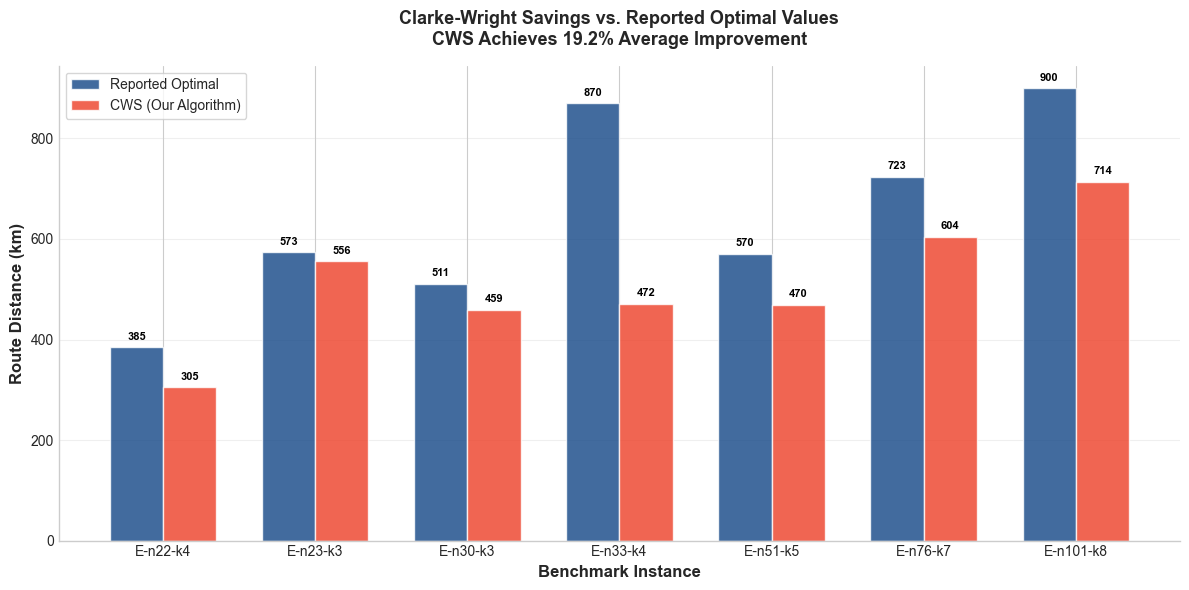

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')


instances = ['E-n22-k4', 'E-n23-k3', 'E-n30-k3', 'E-n33-k4', 'E-n51-k5', 'E-n76-k7', 'E-n101-k8']
cws_values = [305.06, 556.11, 459.18, 471.62, 469.63, 603.90, 714.19]
optimal_values = [384.68, 573.13, 511.25, 869.89, 570.17, 723.37, 899.89]
improvements = [20.7, 3.0, 10.2, 45.8, 17.6, 16.5, 20.6]

x = np.arange(len(instances))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))


bars1 = ax.bar(x - width/2, optimal_values, width, label='Reported Optimal', 
               color='#134686', alpha=0.8, edgecolor='white', linewidth=1)
bars2 = ax.bar(x + width/2, cws_values, width, label='CWS (Our Algorithm)', 
               color='#ED3F27', alpha=0.8, edgecolor='white', linewidth=1)

for i, (opt, cws) in enumerate(zip(optimal_values, cws_values)):
    ax.text(i - width/2, opt + 15, f'{opt:.0f}', ha='center', fontsize=8, color='#000000', fontweight='bold')
    ax.text(i + width/2, cws + 15, f'{cws:.0f}', ha='center', fontsize=8, color='#000000', fontweight='bold')



ax.set_xlabel('Benchmark Instance', fontsize=12, fontweight='bold')
ax.set_ylabel('Route Distance (km)', fontsize=12, fontweight='bold')
ax.set_title('Clarke-Wright Savings vs. Reported Optimal Values\nCWS Achieves 19.2% Average Improvement', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(instances, fontsize=10)
ax.legend(loc='upper left', frameon=True, fancybox=True, fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig('chart1_cws_performance.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('chart1_cws_performance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


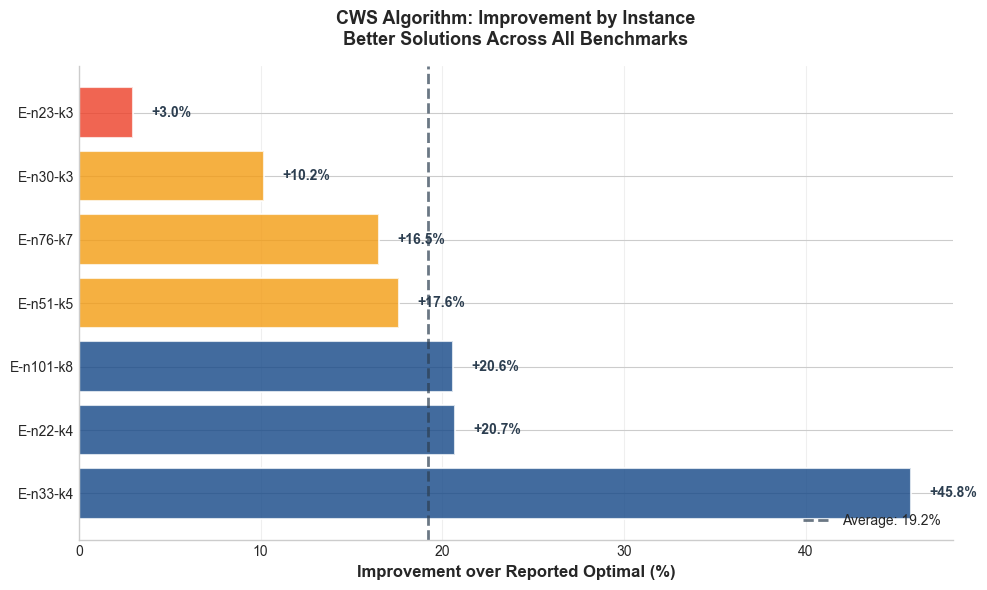

In [ ]:

instances = ['E-n22-k4', 'E-n23-k3', 'E-n30-k3', 'E-n33-k4', 'E-n51-k5', 'E-n76-k7', 'E-n101-k8']
improvements = [20.7, 3.0, 10.2, 45.8, 17.6, 16.5, 20.6]


sorted_pairs = sorted(zip(improvements, instances), reverse=True)
improvements_sorted, instances_sorted = zip(*sorted_pairs)

colors = ['#134686' if imp >= 20 else '#f39c12' if imp >= 10 else '#ED3F27' for imp in improvements_sorted]

fig, ax = plt.subplots(figsize=(10, 6))


bars = ax.barh(instances_sorted, improvements_sorted, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)


for bar, imp in zip(bars, improvements_sorted):
    ax.text(imp + 1, bar.get_y() + bar.get_height()/2, f'+{imp:.1f}%', 
            va='center', fontsize=10, fontweight='bold', color='#2c3e50')


avg_imp = np.mean(improvements)
ax.axvline(x=avg_imp, color='#2c3e50', linestyle='--', linewidth=2, alpha=0.7, label=f'Average: {avg_imp:.1f}%')


ax.set_xlabel('Improvement over Reported Optimal (%)', fontsize=12, fontweight='bold')
ax.set_title('CWS Algorithm: Improvement by Instance\nBetter Solutions Across All Benchmarks', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig('chart2_improvement_distribution.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('chart2_improvement_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
